# Line Chart

`GraphMtplt.graph_line()` generates line charts for time series or any indexed dataframe.

---

## Expected DataFrame

```text
Date          SPX      NASDAQ
2024-01-31    100      150
2024-02-29    105      152
2024-03-31    108      160
```

- The index represents the X-axis.
- The columns represent the data series.

---
## Basic Example

In [1]:
import helpers_ps as hp
import pandas as pd

Setting graph theme

In [2]:
hp.set_graph_theme()

Creating a `pd.Dataframe`

In [16]:
df = pd.DataFrame({
    "date": pd.date_range("2024-01-01", periods=12, freq="ME"),
    "return": [0.01, 0.02, -0.005, 0.015, 0.012, 0.018, -0.003, 0.009, 0.011, 0.014, 0.006, 0.013],
    "nav": [101, 103, 101.5, 102, 104, 106, 105, 106.5, 107, 108, 109, 108.5],
    "navy": [-101, 103, -101.5, 102, -104, 106, 105, 106.5, 107, 108, 109, 108.5]
}).set_index("date")

display(df)

,return,nav,navy
date,,,
2024-01-31,0.010,101.0,-101.0
2024-02-29,0.020,103.0,103.0
2024-03-31,-0.005,101.5,-101.5
2024-04-30,0.015,102.0,102.0
2024-05-31,0.012,104.0,-104.0
2024-06-30,0.018,106.0,106.0
2024-07-31,-0.003,105.0,105.0
2024-08-31,0.009,106.5,106.5
2024-09-30,0.011,107.0,107.0


# Simple Line Graph

The [`graph_line()`](../../api/GraphMtplt/graphs#line-graph) method allows to create a line graph over the existing ploted figure. When the series is not specified all columns are graphed on the same plot

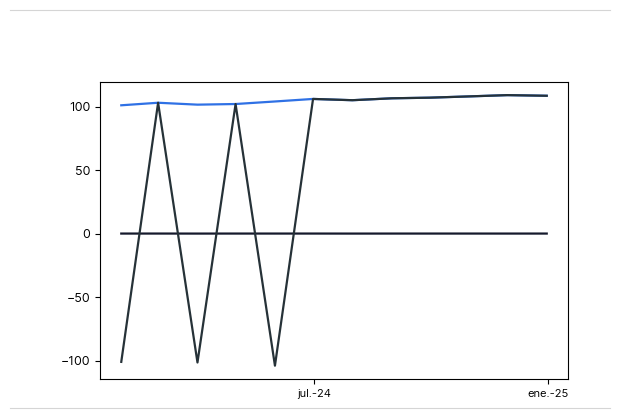

In [17]:
g = (
    hp.GraphMtplt(df)
    .graph_line()
)

---
## Multiple Series

When dataframe contains multiple columns and only a subset is to be graphed, the `series` parameter allows for customization

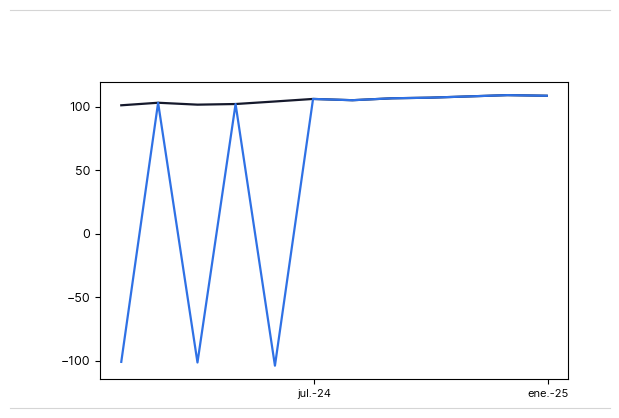

In [19]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"nav"},
            {"ticker":"navy"}
        ]
    )
)

### Series customization

The `series` parameter allows for customization of the series from color to lineweight 

In [23]:
series = [
    {
        "ticker":"nav",                 # Ticker reference
        "label":"Net Asset Value",      # Label adjustment
        "axis_side": "right",           # Axis side ["left", "righ"]
        "color": "red",               # Line color
        "linestyle":"--",               # Line style ["-", "--", etc]
        "lw":1,                         # Line Weight
        "tags": [{}]                    # List of typeddict that allows for the inclusion of tags
    },
    {
        "ticker":"return",                 
        "label":"Portfolio Return",      
        "axis_side": "left",           
        "color": "green",               
        "linestyle":"-",               
        "lw":2,                         
        "tags": [{}]                    
    }
]

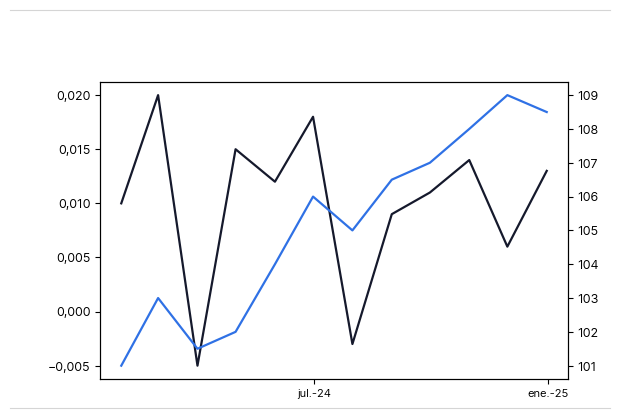

In [26]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"return", "axis_side":"left"},
            {"ticker":"nav", "axis_side":"right"}
        ]
    )
)

---
#### Customize series labels

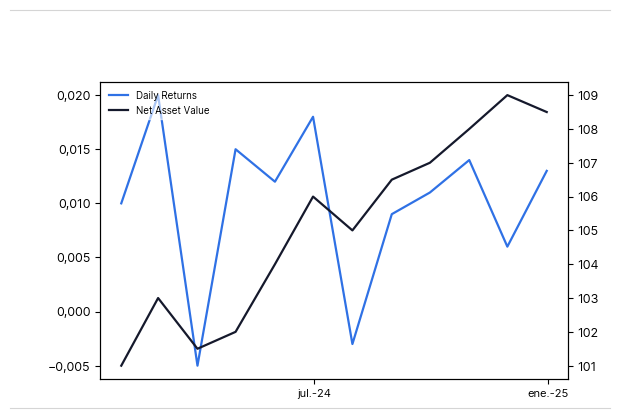

In [7]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"nav", "label":"Net Asset Value", "axis_side":"right"},
            {"ticker":"return", "label":"Daily Returns"}
        ]
    )
    .add_legend()
)

---
#### Customize Colors

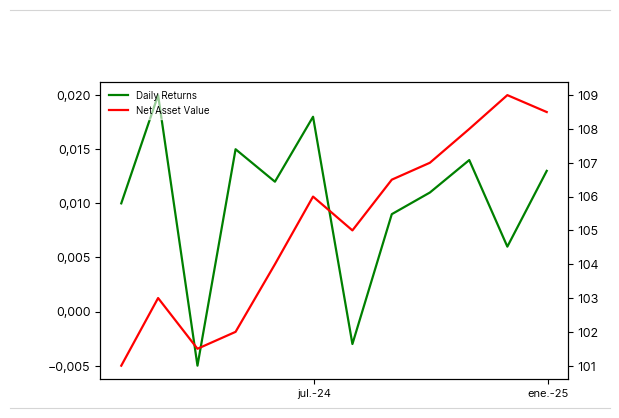

In [8]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"nav", "label":"Net Asset Value", "axis_side":"right", "color":"red"},
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ]
    )
    .add_legend()
)

---
## Title, Subtitle, and Source

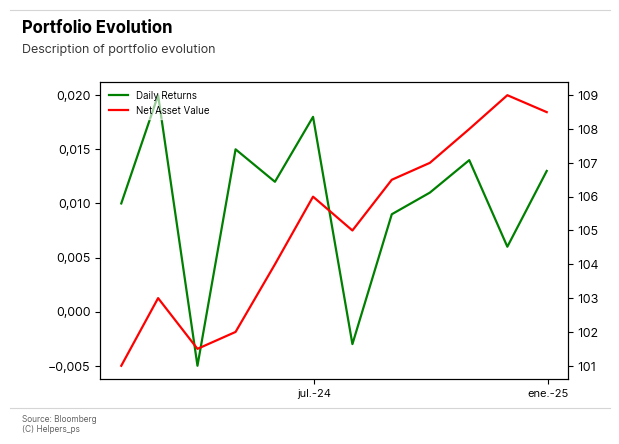

In [9]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"nav", "label":"Net Asset Value", "axis_side":"right", "color":"red"},
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ]
    )
    .add_legend()
    .add_title("Portfolio Evolution")
    .add_subtitle("Description of portfolio evolution")
    .add_source(["Source: Bloomberg", "(C) Helpers_ps"])
)

---
## Bloomberg Format on X-Axis

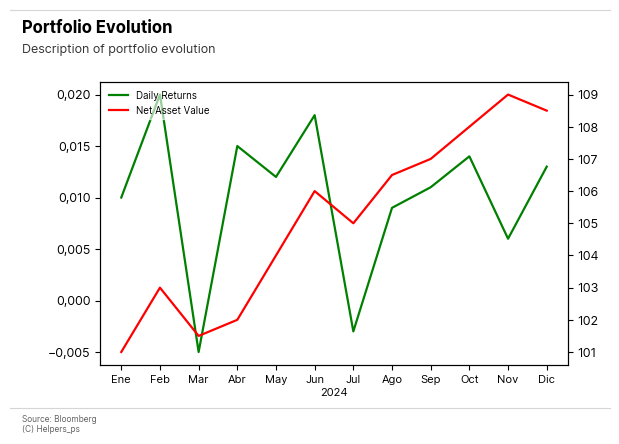

In [10]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {"ticker":"nav", "label":"Net Asset Value", "axis_side":"right", "color":"red"},
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ],
        x_axis={
            "bbg_format":True,
            "tick_step":1
        }
    )
    .add_legend()
    .add_title("Portfolio Evolution")
    .add_subtitle("Description of portfolio evolution")
    .add_source(["Source: Bloomberg", "(C) Helpers_ps"])
)

---
## Show Last Value

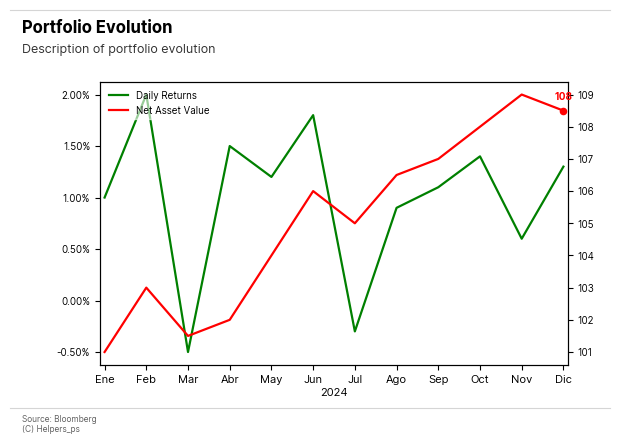

In [11]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {
                "ticker":"nav", 
                "label":"Net Asset Value", 
                "axis_side":"right", 
                "color":"red",
                "tags":[
                    {
                        "x_values":"last",
                        "template":"{y_value:,.0f}",
                        "tag":{
                            "ubic_etq": (0,10),
                            "fontweight":"bold"
                        }
                    }
                ]
            },
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ],
        x_axis={
            "bbg_format":True,
            "tick_step":1
        }
    )
    .config_yaxis(
        side="left",
        fmt=",.2%"
    )
    .config_yaxis(
        side="right",
        fmt=",.0f"
    )
    .add_legend()
    .add_title("Portfolio Evolution")
    .add_subtitle("Description of portfolio evolution")
    .add_source(["Source: Bloomberg", "(C) Helpers_ps"])
)

---
## Add Horizontal Lines

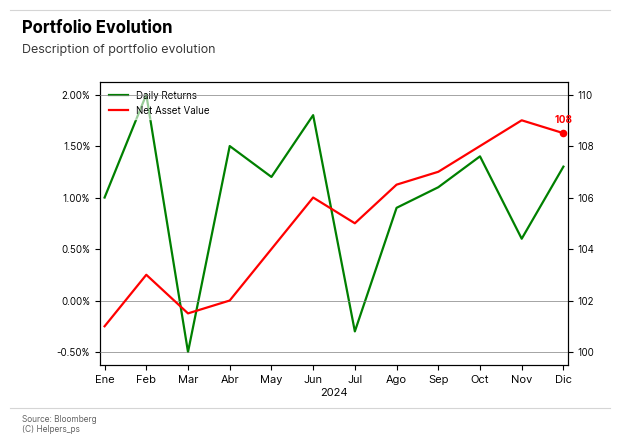

In [12]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {
                "ticker":"nav", 
                "label":"Net Asset Value", 
                "axis_side":"right", 
                "color":"red",
                "tags":[
                    {
                        "x_values":"last",
                        "template":"{y_value:,.0f}",
                        "tag":{
                            "ubic_etq": (0,10),
                            "fontweight":"bold"
                        }
                    }
                ]
            },
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ],
        x_axis={
            "bbg_format":True,
            "tick_step":1
        }
    )
    .config_yaxis(
        side="left",
        fmt=",.2%"
    )
    .config_yaxis(
        side="right",
        fmt=",.0f"
    )
    .add_legend()
    .add_title("Portfolio Evolution")
    .add_subtitle("Description of portfolio evolution")
    .add_source(["Source: Bloomberg", "(C) Helpers_ps"])
    .horizontal_lines([0])
    .horizontal_lines([100,110], side="right")
)

---
## Add Horizontal Guides

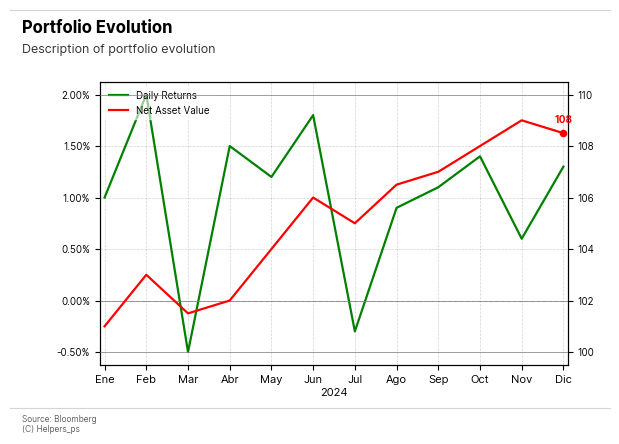

In [13]:
g = (
    hp.GraphMtplt(df)
    .graph_line(
        series=[
            {
                "ticker":"nav", 
                "label":"Net Asset Value", 
                "axis_side":"right", 
                "color":"red",
                "tags":[
                    {
                        "x_values":"last",
                        "template":"{y_value:,.0f}",
                        "tag":{
                            "ubic_etq": (0,10),
                            "fontweight":"bold"
                        }
                    }
                ]
            },
            {"ticker":"return", "label":"Daily Returns", "color":"green"}
        ],
        x_axis={
            "bbg_format":True,
            "tick_step":1
        }
    )
    .config_yaxis(
        side="left",
        fmt=",.2%"
    )
    .config_yaxis(
        side="right",
        fmt=",.0f"
    )
    .add_legend()
    .add_title("Portfolio Evolution")
    .add_subtitle("Description of portfolio evolution")
    .add_source(["Source: Bloomberg", "(C) Helpers_ps"])
    .horizontal_lines([0])
    .horizontal_lines([100,110], side="right")
    .horizontal_guides()
    .vertical_guides()
)

---
## Typical Use Cases

- Equity indices.
- Exchange rates.
- Inflation.
- Rates and yields.
- Macroeconomic indicators.
- Cumulative portfolio performance.